In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

college = pd.read_csv('College.csv', index_col=0)
college.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Private,,,,,,,,,,,,,,,,,
Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [2]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


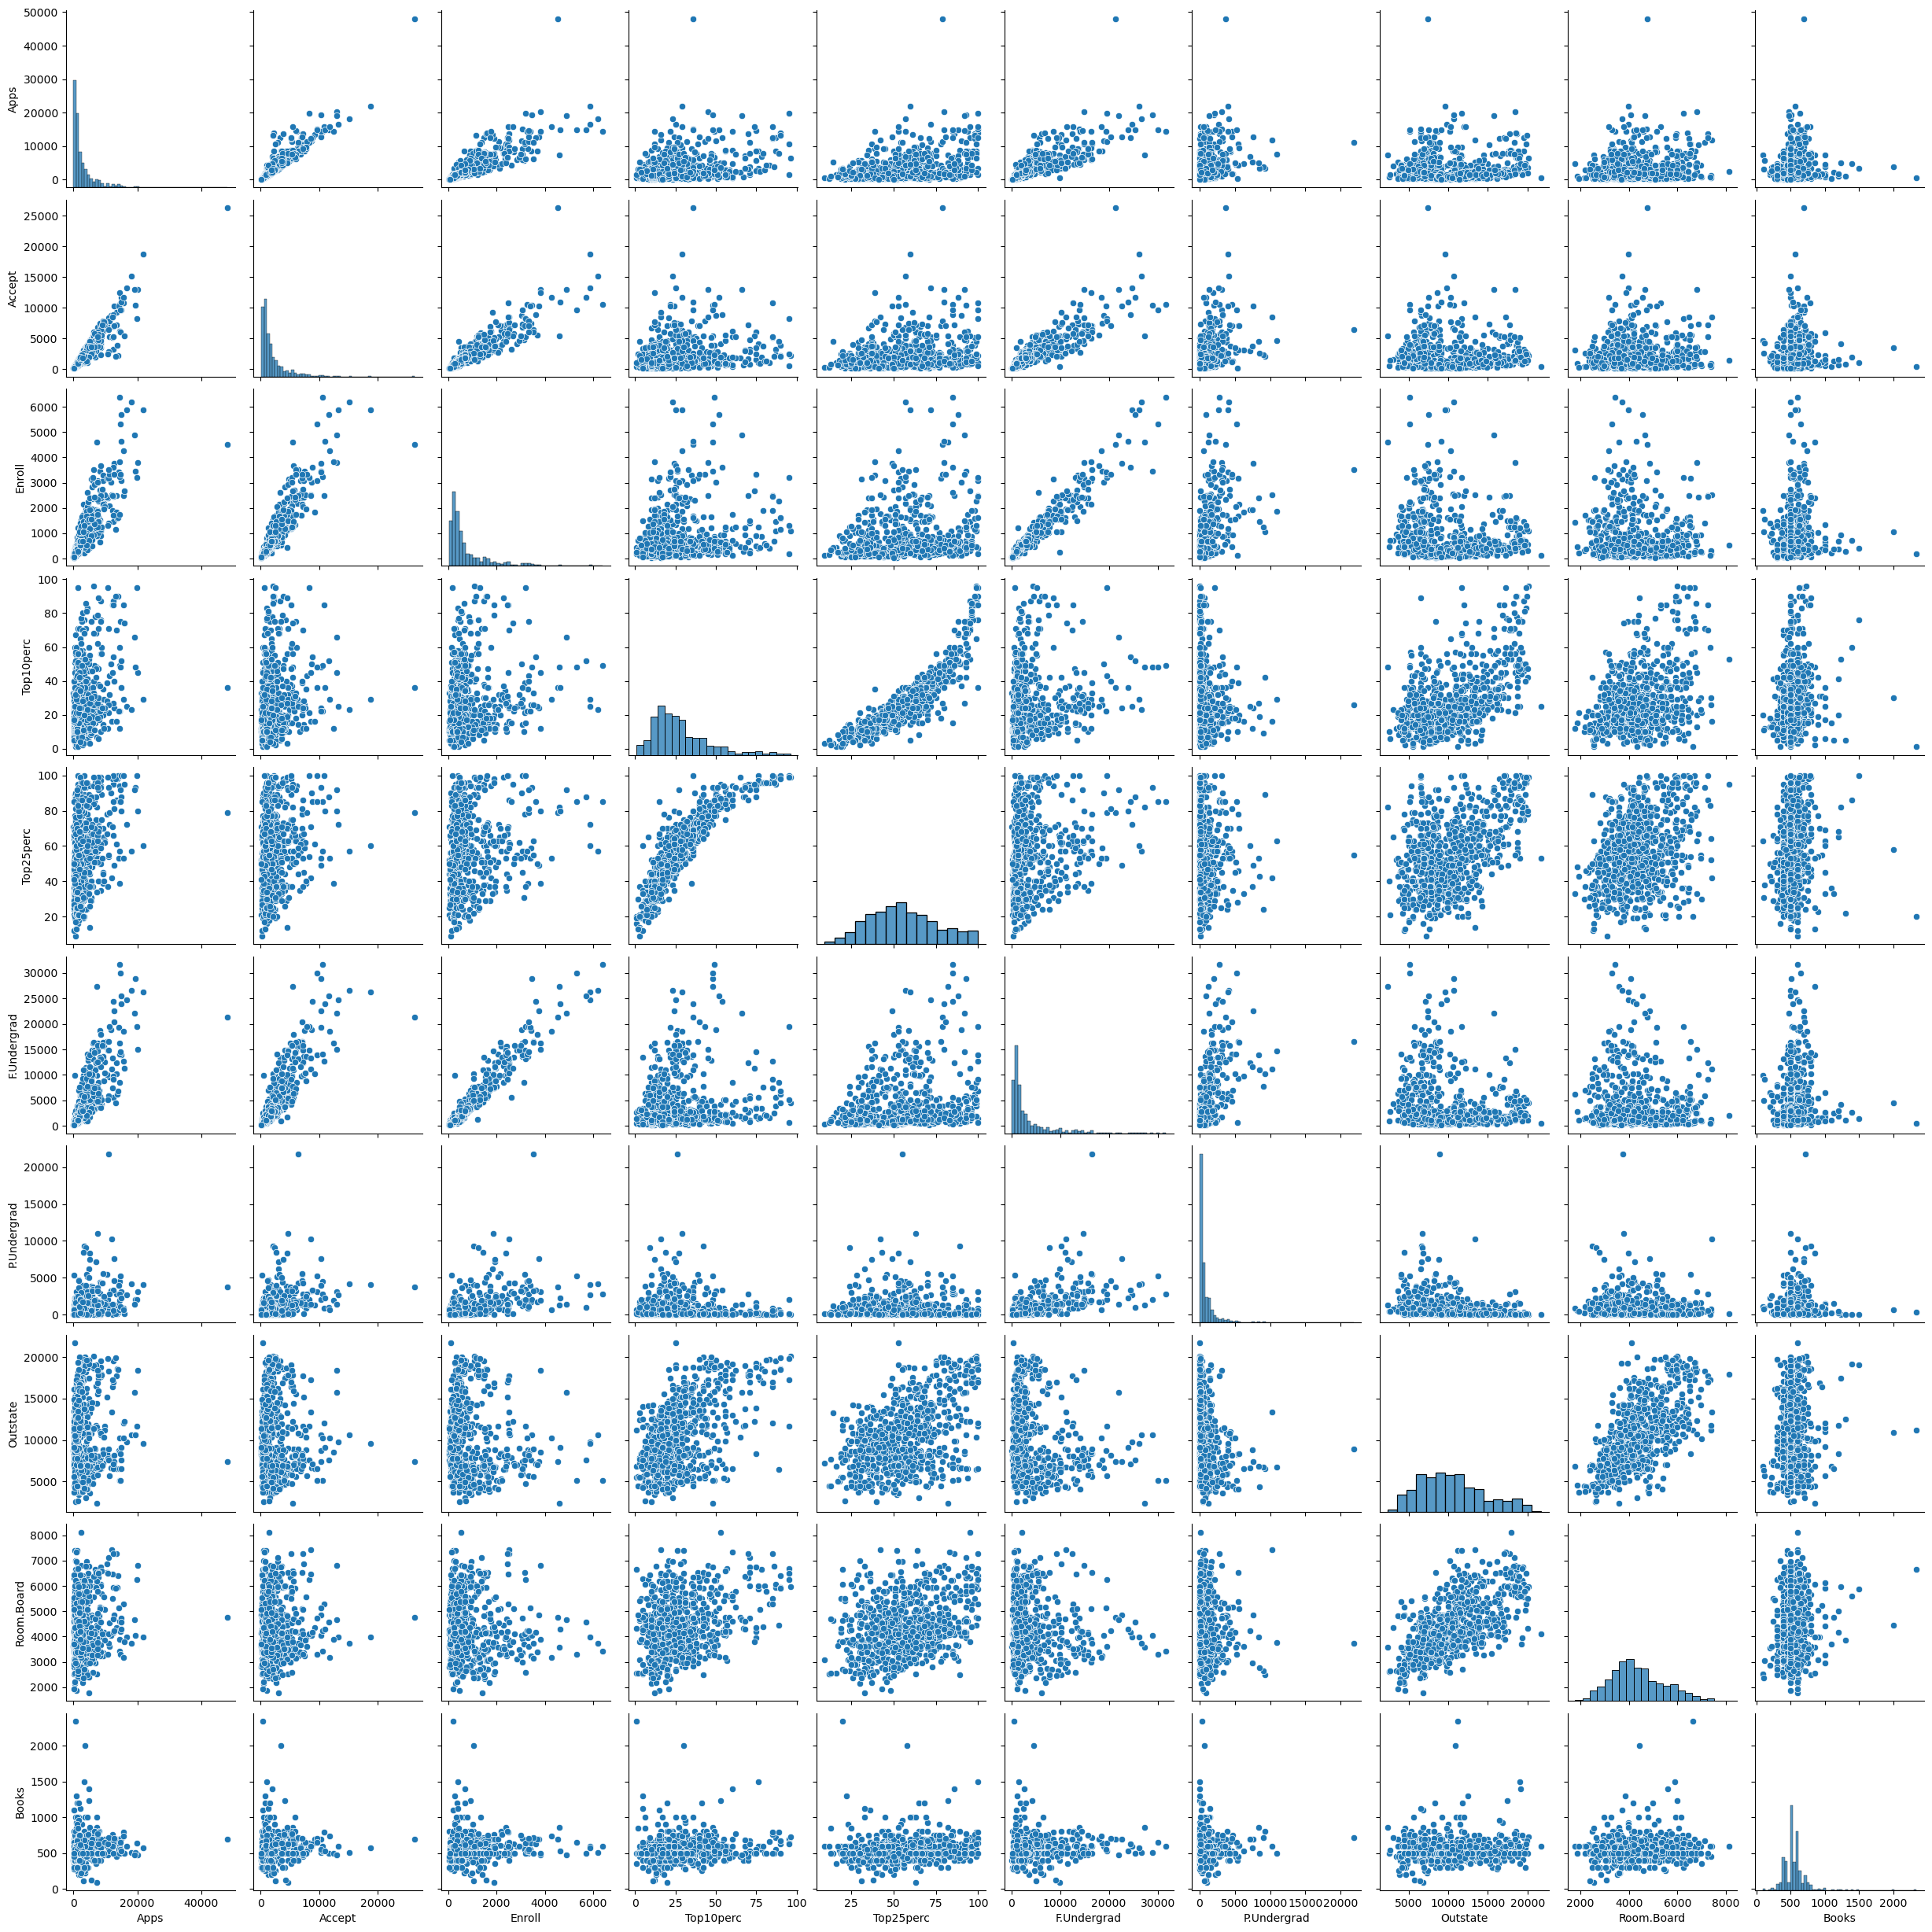

In [3]:
sns.pairplot(college.iloc[:, :10])
plt.show()

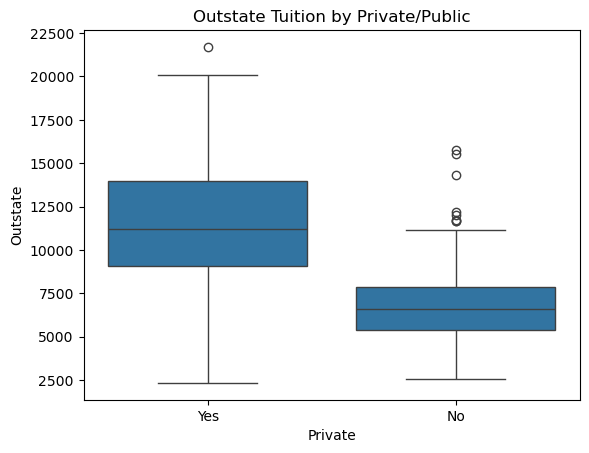

In [4]:
sns.boxplot(x='Private', y='Outstate', data=college)
plt.title('Outstate Tuition by Private/Public')
plt.show()

Elite
No     699
Yes     78
Name: count, dtype: int64


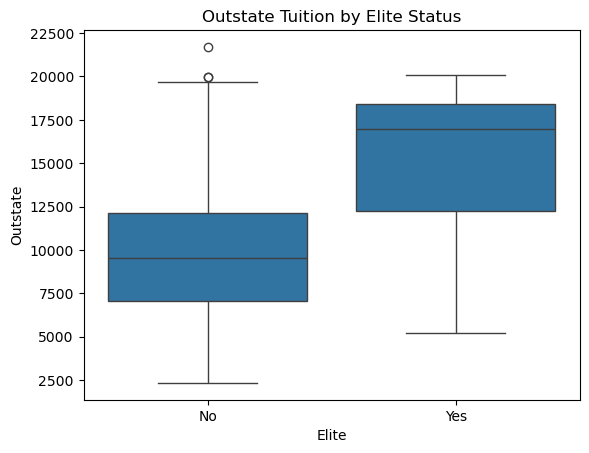

In [5]:
college['Elite'] = pd.cut(college['Top10perc'], bins=[-1, 50, 100], labels=['No', 'Yes'])
print(college['Elite'].value_counts())

sns.boxplot(x='Elite', y='Outstate', data=college)
plt.title('Outstate Tuition by Elite Status')
plt.show()

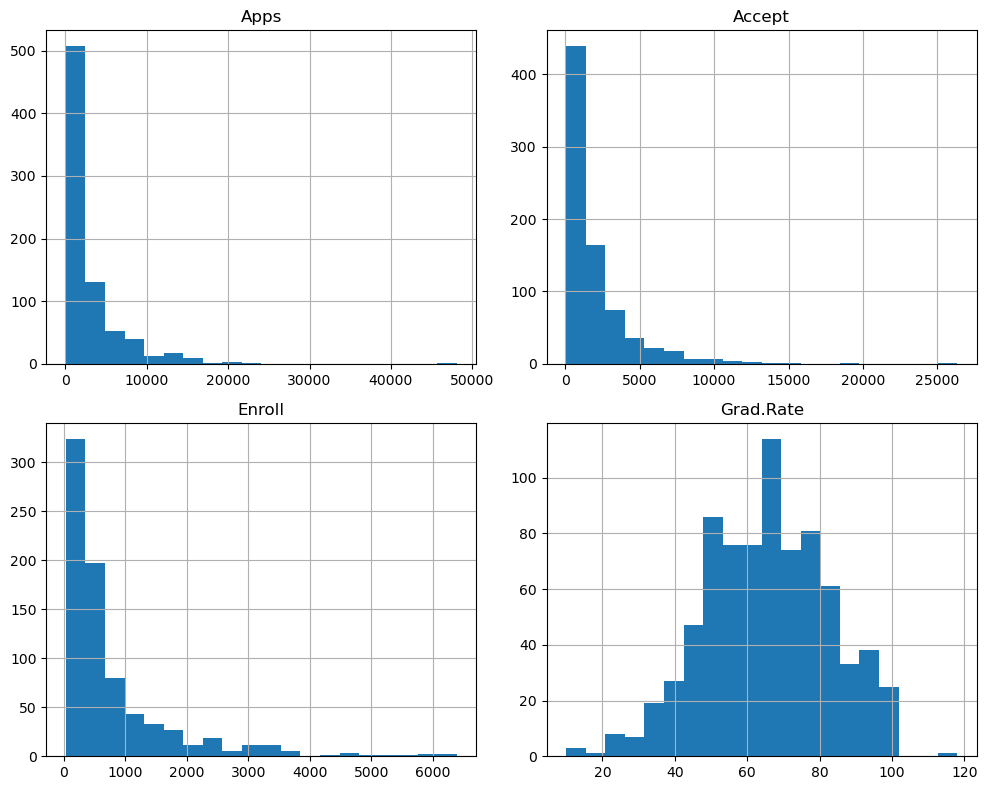

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
college['Apps'].hist(ax=axes[0,0], bins=20)
axes[0,0].set_title('Apps')

college['Accept'].hist(ax=axes[0,1], bins=20)
axes[0,1].set_title('Accept')

college['Enroll'].hist(ax=axes[1,0], bins=20)
axes[1,0].set_title('Enroll')

college['Grad.Rate'].hist(ax=axes[1,1], bins=20)
axes[1,1].set_title('Grad.Rate')
plt.tight_layout()
plt.show()

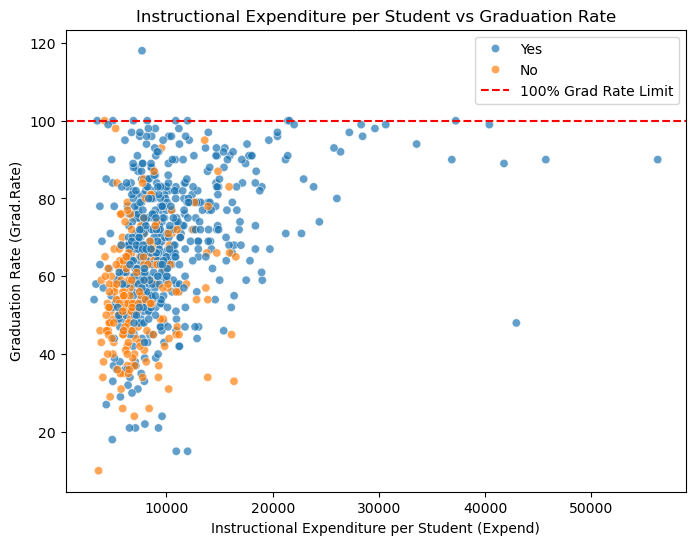

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=college, x='Expend', y='Grad.Rate', hue='Private', alpha=0.7)
plt.title('Instructional Expenditure per Student vs Graduation Rate')
plt.xlabel('Instructional Expenditure per Student (Expend)')
plt.ylabel('Graduation Rate (Grad.Rate)')
plt.axhline(100, color='red', linestyle='--', label='100% Grad Rate Limit')
plt.legend()
plt.show()

Claim:One might claim that higher instructional expenditure per student (Expend) strictly and linearly leads to a higher graduation rate (Grad.Rate).

Supporting Figure & Explanation:
As shown in the scatterplot above, while there is an initial positive trend, the relationship plateaus significantly once expenditure exceeds $20,000 per student. Beyond this point, additional spending yields diminishing returns on graduation rates, with several ultra-high-spending private colleges achieving graduation rates comparable to mid-spending ones. Furthermore, the plot exposes an obvious data anomaly where one college reports a graduation rate above 100% (118%), demonstrating that spending alone is not a strictly reliable linear predictor of student completion.